In [ ]:
# Mevcut setup dosyasını oku
with open("/content/drive/MyDrive/imdb_peft_project/code/lora-imdb-classifier/00_colab_setup.py", "r") as f:
    content = f.read()

# !git komutlarını subprocess ile değiştir
content = content.replace(
    '!git config --global user.email "{GITHUB_EMAIL}"',
    'subprocess.run(f\'git config --global user.email "{GITHUB_EMAIL}"\', shell=True)'
)
content = content.replace(
    '!git config --global user.name  "{GITHUB_USERNAME}"',
    'subprocess.run(f\'git config --global user.name "{GITHUB_USERNAME}"\', shell=True)'
)
content = content.replace(
    '!git clone {REPO_URL} {REPO_PATH}',
    'subprocess.run(f"git clone {REPO_URL} {REPO_PATH}", shell=True)'
)
content = content.replace(
    '!cd {REPO_PATH} && git remote set-url origin {REPO_URL}',
    'subprocess.run(f"cd {REPO_PATH} && git remote set-url origin {REPO_URL}", shell=True)'
)
content = content.replace(
    '!cd {REPO_PATH} && git pull',
    'subprocess.run(f"cd {REPO_PATH} && git pull", shell=True)'
)

# Kaydet
with open("/content/drive/MyDrive/imdb_peft_project/code/lora-imdb-classifier/00_colab_setup.py", "w") as f:
    f.write(content)

print("✓ Düzeltildi.")

✓ Düzeltildi.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
exec(open("/content/drive/MyDrive/imdb_peft_project/code/lora-imdb-classifier/00_colab_setup.py").read())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ /content/drive/MyDrive/imdb_peft_project
✓ /content/drive/MyDrive/imdb_peft_project/checkpoints/roberta_lora
✓ /content/drive/MyDrive/imdb_peft_project/checkpoints/deberta_lora
✓ /content/drive/MyDrive/imdb_peft_project/oof_predictions
✓ /content/drive/MyDrive/imdb_peft_project/results
✓ /content/drive/MyDrive/imdb_peft_project/notebooks
✓ /content/drive/MyDrive/imdb_peft_project/code

Folder structure ready.
Enter GitHub Token: ··········
Repository exists, pulling latest changes...
✓ Pull complete.

Repository path: /content/drive/MyDrive/imdb_peft_project/code/lora-imdb-classifier
SETUP COMPLETE
Drive folder  : /content/drive/MyDrive/imdb_peft_project
GitHub repo   : /content/drive/MyDrive/imdb_peft_project/code/lora-imdb-class

In [ ]:
!pip install transformers datasets peft accelerate scikit-learn -q

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import RobertaTokenizer, DebertaV2Tokenizer
from torch.utils.data import Dataset
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✓ All imports ready.")

✓ All imports ready.


In [ ]:
dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset["train"])
test_df  = pd.DataFrame(dataset["test"])

print(f"Train : {len(train_df)} samples")
print(f"Test  : {len(test_df)} samples")
print(f"\nLabel distribution (train):\n{train_df['label'].value_counts()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train : 25000 samples
Test  : 25000 samples

Label distribution (train):
label
0    12500
1    12500
Name: count, dtype: int64


In [ ]:
def clean_text(text: str, lowercase: bool = False) -> str:
    """
    IMDB-specific text cleaning.

    lowercase=False  → for transformer models (RoBERTa, DeBERTa)
                       Capitalization carries sentiment signal:
                       'TERRIBLE' != 'terrible'
    lowercase=True   → for TF-IDF + SVM baseline
    """
    text = re.sub(r"<[^>]+>", " ", text)  # Remove HTML tags
    text = re.sub(r"\s+", " ", text)       # Normalize whitespace
    text = text.strip()
    if lowercase:
        text = text.lower()
    return text

# Apply cleaning
train_df["text_clean"]       = train_df["text"].apply(clean_text)
test_df["text_clean"]        = test_df["text"].apply(clean_text)
train_df["text_clean_lower"] = train_df["text"].apply(lambda x: clean_text(x, lowercase=True))
test_df["text_clean_lower"]  = test_df["text"].apply(lambda x: clean_text(x, lowercase=True))

# Verify
sample_idx = train_df["text"].str.contains(r"[A-Z]{3,}").idxmax()
print("Original :", train_df["text"].iloc[sample_idx][:150])
print("\nTransformer:", train_df["text_clean"].iloc[sample_idx][:150])
print("\nSVM        :", train_df["text_clean_lower"].iloc[sample_idx][:150])

Original : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th

Transformer: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard th

SVM        : i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard th


Average words : 234
Median words  : 174
Max words     : 2470
Over 512      : 1903 (7.6%)


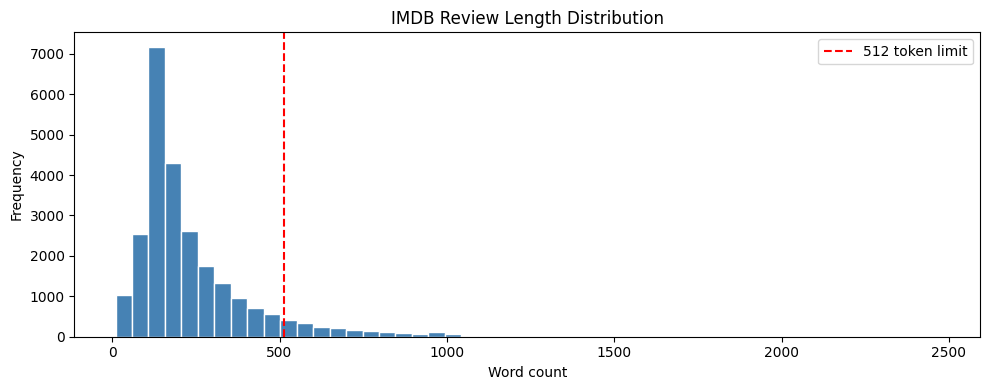

✓ Figure saved to Drive.


In [ ]:
train_df["word_count"] = train_df["text"].apply(lambda x: len(x.split()))

print(f"Average words : {train_df['word_count'].mean():.0f}")
print(f"Median words  : {train_df['word_count'].median():.0f}")
print(f"Max words     : {train_df['word_count'].max()}")
print(f"Over 512      : {(train_df['word_count'] > 512).sum()} "
      f"({(train_df['word_count'] > 512).mean()*100:.1f}%)")

plt.figure(figsize=(10, 4))
plt.hist(train_df["word_count"], bins=50, color="steelblue", edgecolor="white")
plt.axvline(512, color="red", linestyle="--", label="512 token limit")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.title("IMDB Review Length Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(f"{DIRS['results']}/length_distribution_v2.png", dpi=150)
plt.show()
print("✓ Figure saved to Drive.")

In [ ]:
def head_tail_truncate_v2(text: str, tokenizer, max_len: int = 512,
                          head_len: int = 256) -> dict:
    """
    V2: Equal head+tail strategy — first 256 + last 256 tokens.

    Rationale: Sentiment signals are distributed more evenly
    at both ends. Equal split avoids bias toward either end.

    V1 used head=128, tail=384.
    """
    tail_len = max_len - head_len  # 256

    tokens = tokenizer(
        text,
        add_special_tokens=False,
        truncation=False,
        return_tensors=None
    )
    input_ids      = tokens["input_ids"]
    attention_mask = tokens["attention_mask"]

    if len(input_ids) > max_len - 2:
        input_ids      = input_ids[:head_len] + input_ids[-tail_len:]
        attention_mask = attention_mask[:head_len] + attention_mask[-tail_len:]

    result = tokenizer(
        tokenizer.decode(input_ids),
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors=None
    )
    return result

print("✓ V2 truncation function ready.")
print("  Head: 256 tokens")
print("  Tail: 256 tokens")
print("  Total: 512 tokens")

✓ V2 truncation function ready.
  Head: 256 tokens
  Tail: 256 tokens
  Total: 512 tokens


In [ ]:
print("Loading tokenizers...")
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
deberta_tokenizer = DebertaV2Tokenizer.from_pretrained("microsoft/deberta-v3-base")
print("✓ RoBERTa tokenizer ready.")
print("✓ DeBERTa tokenizer ready.")

Loading tokenizers...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

✓ RoBERTa tokenizer ready.
✓ DeBERTa tokenizer ready.


In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512, head_len=256,
                 text_col="text_clean"):
        """
        V2 Dataset — uses equal head+tail truncation (256/256).

        Args:
            df       : DataFrame with text_clean and label columns
            tokenizer: HuggingFace tokenizer
            max_len  : Maximum sequence length (default 512)
            head_len : Head tokens (default 256, equal split)
            text_col : Column to use ('text_clean' for transformers,
                       'text_clean_lower' for SVM)
        """
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.head_len  = head_len
        self.text_col  = text_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text  = self.df.loc[idx, self.text_col]
        label = self.df.loc[idx, "label"]

        encoding = head_tail_truncate_v2(
            text, self.tokenizer,
            max_len=self.max_len,
            head_len=self.head_len
        )

        return {
            "input_ids":      torch.tensor(encoding["input_ids"],
                                           dtype=torch.long),
            "attention_mask": torch.tensor(encoding["attention_mask"],
                                           dtype=torch.long),
            "labels":         torch.tensor(label, dtype=torch.long),
        }

# Dataset'leri oluştur
print("Creating datasets...")
roberta_train_dataset = IMDBDataset(train_df, roberta_tokenizer)
roberta_test_dataset  = IMDBDataset(test_df,  roberta_tokenizer)
deberta_train_dataset = IMDBDataset(train_df, deberta_tokenizer)
deberta_test_dataset  = IMDBDataset(test_df,  deberta_tokenizer)

# Verify
sample = roberta_train_dataset[0]
print(f"\ninput_ids shape     : {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"label               : {sample['labels'].item()}")
print("\n✓ All datasets ready.")

Creating datasets...

input_ids shape     : torch.Size([512])
attention_mask shape: torch.Size([512])
label               : 0

✓ All datasets ready.


In [ ]:
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

sample_df = train_df.head(500).copy()
sample_df["token_count"] = sample_df["text_clean"].apply(
    lambda x: len(
        roberta_tokenizer(x, add_special_tokens=False,
                         truncation=False)["input_ids"]
    )
)

truncated = (sample_df["token_count"] > 512).sum()
print(f"Samples requiring truncation : {truncated} / 500 ({truncated/5:.1f}%)")
print(f"Head+Tail strategy applied   : 256 head + 256 tail tokens")
print(f"\nV1 comparison: 128 head + 384 tail tokens")

hf_logging.set_verbosity_warning()

Samples requiring truncation : 51 / 500 (10.2%)
Head+Tail strategy applied   : 256 head + 256 tail tokens

V1 comparison: 128 head + 384 tail tokens


In [ ]:
# DataFrames'i Drive'a kaydet
train_df.to_parquet(f"{DIRS['root']}/train_df_v2.parquet")
test_df.to_parquet(f"{DIRS['root']}/test_df_v2.parquet")
print("✓ DataFrames saved to Drive.")

# Notebook'u .py'a çevir ve push'la
NOTEBOOK_NAME = "01b_data_preprocessing_v2"

!jupyter nbconvert --to script \
  "/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}.ipynb" \
  --output-dir "/content/"

import os
os.rename(f"/content/{NOTEBOOK_NAME}.txt",
          f"/content/{NOTEBOOK_NAME}.py")

save_code_to_repo(f"/content/{NOTEBOOK_NAME}.py")
push_to_github("v2 data preprocessing complete - 256/256 head+tail")

✓ DataFrames saved to Drive.
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/01b_data_preprocessing_v2.ipynb to script
[NbConvertApp] Writing 8757 bytes to /content/01b_data_preprocessing_v2.txt
✓ 01b_data_preprocessing_v2.py → copied to repository.
✓ Pushed to GitHub: 'v2 data preprocessing complete - 256/256 head+tail'
